# Поиска инсайтов и точек роста

С данными сервиса доставки еды «Всё.из.кафе» вы уже работали в одном из проектов базового курса. Тогда вы описывали ключевые метрики продукта — количество пользователей, заказов и выручку.

Однако конкуренты сервиса не дремлют, и руководство ждёт от продукта роста. Найти инсайты, которые позволят сервису повысить показатель удержания пользователей и улучшить взаимодействие с партнёрами, поручено продуктовому аналитику, то есть вам.

Вам необходимо помочь бизнесу ответить на следующие вопросы:
- Как ведут себя пользователи? Как наиболее эффективно выстроить работу с ними, чтобы они продолжали пользоваться продуктом?
- Какой путь проходят пользователи в сервисе? Где «проваливаются»?
- Как улучшить взаимодействие с партнёрами-ресторанами?

### Задачи 

В рамках данного проекта вы проведёте комплексный анализ данных:
- изучите пользовательский путь и проанализируете конверсии через воронки;
- сегментируете пользователей с помощью RFM-модели для оценки лояльности и поведения клиентов;
- кластеризуете рестораны методом K-Means, чтобы выделить группы с разными моделями работы и разработать персонализированные маркетинговые стратегии.

Такой подход позволит ближе познакомиться с работой сервиса, выявить узкие места и предложить решения для удержания пользователей и повышения эффективности сотрудничества с ресторанами.


### Данные

Данные включают следующие сведения:
      
- `visitor_uuid` — идентификатор посетителя. Это идентификатор, который присваивается системой любому новому пользователю вне зависимости от того, зарегистрировался он в продукте или нет.
- `user_id` — идентификатор зарегистрированного пользователя. Присваивается посетителю после создания учётной записи: ввода логина, пароля, адреса доставки и контактных данных.
- `device_type` — тип платформы, с которой посетитель зашёл в продукт.
- `city_id` — город, из которого посетитель зашёл в сервис.
- `source` — рекламный источник привлечения посетителя.
- `first_date` — дата первого посещения продукта.
- `visit_id` — уникальный идентификатор сессии.
- `event` — название аналитического события.
- `datetime` — дата и время события.
- `rest_id` — уникальный идентификатор ресторана (заполняется для заказов, карточек ресторанов и блюд).
- `object_id` — уникальный идентификатор блюда (заполняется для заказов и карточек блюд).
- `order_id` — уникальный идентификатор заказа.
- `revenue` — выручка от заказа (в рублях). Это та сумма, которую пользователь видит при оплате.
- `delivery` — стоимость доставки (в рублях).
- `commission` — комиссия, которую «Всё.из.кафе» берёт с выручки ресторана, в процентах.

    
### План проекта
- Загрузка данных и их предобработка.
- Анализ пользовательского пути новых пользователей.
- RFM сегментация.
- K-Means кластеризация.
- Итоговый вывод и рекомендации.

## 1. Загрузка данных и их предобработка

Загрузите данные и получите первую информацию о них. Проведите необходимую предобработку. Основную информацию о данных и этапы предобработки зафиксируйте в кратком промежуточном выводе.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from itertools import combinations

In [2]:
data_path = 'https://code.s3.yandex.net/datasets/insides_data.csv'
df = pd.read_csv(data_path, parse_dates=['first_date','datetime'])
df

,visitor_uuid,user_id,device_type,city_id,source,first_date,visit_id,event,datetime,rest_id,object_id,order_id,revenue,delivery,commission
0,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,authorization,2021-05-01 16:07:53,NaN,NaN,NaN,NaN,NaN,NaN
1,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,reg_page,2021-05-01 16:09:16,NaN,NaN,NaN,NaN,NaN,NaN
2,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,confirm_phone,2021-05-01 16:09:19,NaN,NaN,NaN,NaN,NaN,NaN
3,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,login,2021-05-01 16:09:23,NaN,NaN,NaN,NaN,NaN,NaN
4,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,main_page,2021-05-01 16:09:34,2c6095730b514c189ee41c65f03febc3,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205505,fa03bc4e-a8d6-45b2-9df0-29e6e8449fd8,641931.0,Desktop,6,organic,2021-06-28,193825829,authorization,2021-07-01 14:02:36,NaN,NaN,NaN,NaN,NaN,NaN
205506,fa03bc4e-a8d6-45b2-9df0-29e6e8449fd8,641931.0,Desktop,6,organic,2021-06-28,193825829,main_page,2021-07-01 14:22:00,56edd124dfa44656afe0c0d041eba562,NaN,NaN,NaN,NaN,NaN
205507,fbf7a714-cb1d-492a-ae30-b45d02b44989,616472.0,Desktop,6,organic,2021-07-01,193987971,login,2021-07-02 00:11:57,NaN,NaN,NaN,NaN,NaN,NaN
205508,fbf7a714-cb1d-492a-ae30-b45d02b44989,616472.0,Desktop,6,organic,2021-07-01,193987971,add_to_cart,2021-07-02 00:12:05,8c9307a1485d4f8aa48c6746e46540d8,27807.0,675680.0,1400.0,28.0,0.05


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205510 entries, 0 to 205509
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   visitor_uuid  205510 non-null  object        
 1   user_id       205510 non-null  float64       
 2   device_type   205510 non-null  object        
 3   city_id       205510 non-null  int64         
 4   source        205510 non-null  object        
 5   first_date    205510 non-null  datetime64[ns]
 6   visit_id      205510 non-null  int64         
 7   event         205510 non-null  object        
 8   datetime      205510 non-null  datetime64[ns]
 9   rest_id       166915 non-null  object        
 10  object_id     21308 non-null   float64       
 11  order_id      7008 non-null    float64       
 12  revenue       7008 non-null    float64       
 13  delivery      7008 non-null    float64       
 14  commission    21308 non-null   float64       
dtypes: datetime64[ns]

Данные содержат много пропусков в столбцах: `rest_id`, `order_id`, `revenue`, `delivery`. Но это не ошибка, по сути это пропуски по смыслу (Missing Not Applicable), так как, например, не все пользователи сделали заказ.

In [4]:
print(f'Явных дубликатов: {df.duplicated().sum()}')

for col in ['source', 'device_type', 'event']:
    print(f"{col}: {df[col].unique()}")


Явных дубликатов: 0
source: ['Source_B' 'organic' 'Source_A' 'Source_C']
device_type: ['Desktop' 'Mobile']
event: ['authorization' 'reg_page' 'confirm_phone' 'login' 'main_page'
 'object_page' 'add_to_cart' 'order']


Явных и неявных дубликатов нет

In [5]:
print('Минимальная и максимальная дата datetime:', df['datetime'].min(), df['datetime'].max())

Минимальная и максимальная дата datetime: 2021-05-01 00:10:55 2021-07-02 00:12:08


Результаты предобработки показывают что данные хорошего качества, диапазон дат от 2021-05-01 до 2021-07-02

---

## 2. Анализ пользовательского пути

Маркетологи стали замечать следующее: деньги на рекламу по-прежнему тратятся, а заказов стало меньше. И это несмотря на то, что приложение скачивается и устанавливается так же активно, как раньше. Складывается ощущение, что пользователи где-то теряются. При этом доля заказов с десктопной версии приложения увеличилась по сравнению с мобильной.

Разработчики говорят, что последние обновления мобильной версии приложения не должны были повлиять на каталог блюд или его выбор для заказа и последующей оплаты доставки, так как изменения касались нового алгоритма подтверждения мобильного телефона и адреса доставки.

С помощью воронок изучите общий пользовательский путь новых пользователей, затем сравните поведение пользователей мобильной и десктопной версий приложения. 

**Задача 2.1.** Постройте и визуализируйте общую воронку (по всем данным), затем опишите пользовательский путь: какие этапы представлены, какова их последовательность, на каком (или на каких) этапах теряется большая часть новых пользователей.
    
При решении постройте две воронки: 
- **классическую воронку** — доля от первого шага в процентах
- **step-by-step** — с конверсией от предыдущего этапа.

Предполагается, что пользователь проходит такой путь к оформлению доставки блюда из ресторанов:
1. `authorization` — авторизация пользователя — запуск приложения.
2. `main_page` — загрузка основной страницы приложения.
2. `reg_page` — переход на страницу регистрации.
2. `confirm_phone` — подтверждение телефона (окончание процесса регистрации).
2. `object_page` — страница блюда.
2. `add_to_cart` — переход в корзину.
2. `order` — оформление заказа.    

In [6]:
funnel_steps = ['authorization', 'main_page', 'reg_page', 'confirm_phone', 'object_page', 'add_to_cart', 'order']
df_funnel  = df[df['event'].isin(funnel_steps)]
df_funnel_groupped = df_funnel.groupby('event')['user_id'].nunique().reindex(funnel_steps).reset_index(name='users_count')

#обычная конверсия
df_funnel_groupped['CR'] = round(df_funnel_groupped['users_count'] / df_funnel_groupped['users_count'].iloc[0] * 100, 2)

#step by step конверсия
df_funnel_groupped['sbs_CR'] = round(df_funnel_groupped['users_count'] / df_funnel_groupped['users_count'].shift(1) * 100, 2)
df_funnel_groupped

,event,users_count,CR,sbs_CR
0,authorization,7410,100.00,NaN
1,main_page,6537,88.22,88.22
2,reg_page,5417,73.10,82.87
3,confirm_phone,4190,56.55,77.35
4,object_page,3453,46.60,82.41
5,add_to_cart,2899,39.12,83.96
6,order,2416,32.60,83.34


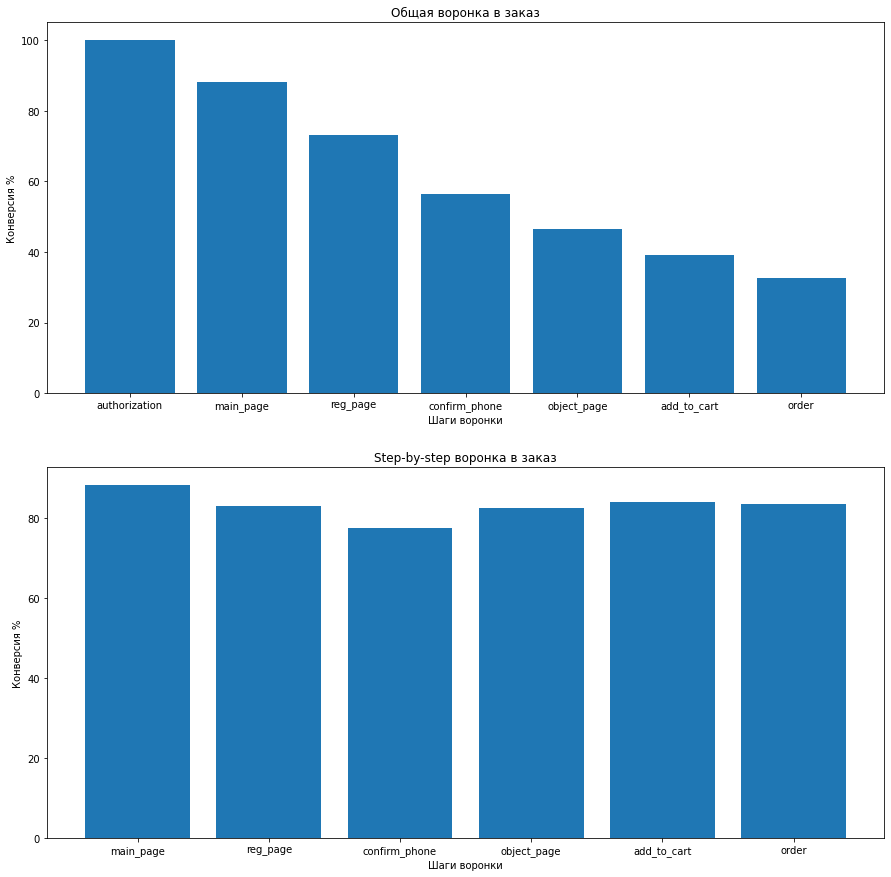

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(15, 15))

axes[0].bar(df_funnel_groupped['event'], df_funnel_groupped['CR'])
axes[0].set_title('Общая воронка в заказ')
axes[0].set_xlabel('Шаги воронки')
axes[0].set_ylabel('Конверсия %')

axes[1].bar(df_funnel_groupped['event'], df_funnel_groupped['sbs_CR'])
axes[1].set_title('Step-by-step воронка в заказ')
axes[1].set_xlabel('Шаги воронки')
axes[1].set_ylabel('Конверсия %')

plt.show()

На данном этапе виднно что в масштабе общей воронки просадок не наблюдается. В то время как Step-by-step воронка показывает небольшую яму на этапах `reg_page` и `confirm_order`, именно эти этапы подверглись изменениям

**Задача 2.2.** Сравните пользовательский путь в двух приложениях: в мобильной версии и десктопной. Для этого постройте и визуализируйте **две воронки step-by-step**: для новых пользователей **мобильной** и **десктопной** версий приложения.
    
Сравните результаты между собой и проанализируйте, есть ли различия в пользовательском пути для различных приложений. Результаты сравнения опишите в небольшом **промежуточном выводе**.

           event  users_count  sbs_CR
0  authorization         4750     NaN
1      main_page         4325   91.05
2       reg_page         3432   79.35
3  confirm_phone         3097   90.24
4    object_page         2657   85.79
5    add_to_cart         2203   82.91
6          order         1814   82.34
           event  users_count  sbs_CR
0  authorization         2810     NaN
1      main_page         2341   83.31
2       reg_page         2069   88.38
3  confirm_phone         1139   55.05
4    object_page          826   72.52
5    add_to_cart          716   86.68
6          order          614   85.75


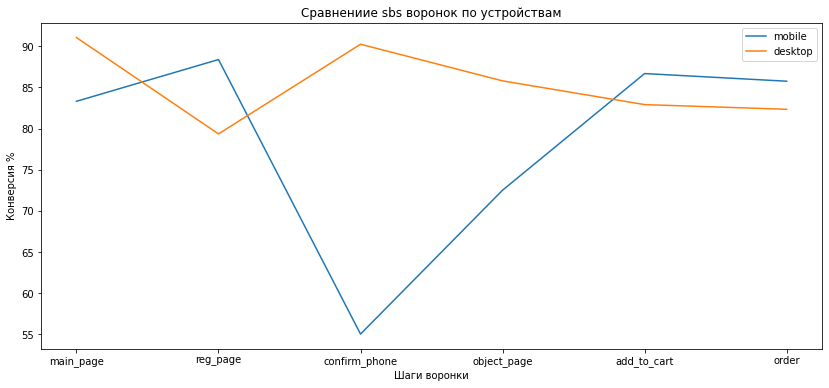

In [8]:
df_funnel_mobile = df_funnel[df_funnel['device_type'] == 'Mobile']
df_funnel_desktop = df_funnel[df_funnel['device_type'] == 'Desktop']

df_funnel_mobile_sbs_CR = df_funnel_mobile.groupby('event')['user_id'].nunique().reindex(funnel_steps).reset_index(name='users_count')
df_funnel_desktop_sbs_CR = df_funnel_desktop.groupby('event')['user_id'].nunique().reindex(funnel_steps).reset_index(name='users_count')
df_funnel_mobile_sbs_CR['sbs_CR'] = round(df_funnel_mobile_sbs_CR['users_count'] /  df_funnel_mobile_sbs_CR['users_count'].shift(1) * 100, 2)
df_funnel_desktop_sbs_CR['sbs_CR'] = round(df_funnel_desktop_sbs_CR['users_count'] /  df_funnel_desktop_sbs_CR['users_count'].shift(1) * 100, 2)

print(df_funnel_desktop_sbs_CR)
print(df_funnel_mobile_sbs_CR)

plt.figure(figsize=(14, 6))
plt.plot(df_funnel_mobile_sbs_CR['event'], df_funnel_mobile_sbs_CR['sbs_CR'], label='mobile')
plt.plot(df_funnel_desktop_sbs_CR['event'], df_funnel_desktop_sbs_CR['sbs_CR'], label='desktop')
plt.legend()
plt.title('Сравнениие sbs воронок по устройствам')
plt.xlabel('Шаги воронки')
plt.ylabel('Конверсия %')
plt.show()

Для пользователей использующих телефоны наблюдается сильный провал на этапе подтверждения номера. Это инсайт - у пользователей с `device` - `mobile` возникают проблемы на этапе подтврждения телефона

---

## 3. RFM сегментация

У сервиса доставки еды не такое высокое удержание пользователей: в первый день возвращается около 14% посетителей, а на седьмой день и того меньше — около 4–5%. Маркетологи хотят запустить несколько рекламных кампаний, направленных на удержание платящих пользователей и их возврат в сервис, если они давно не совершали заказы.

Для этого необходимо сегментировать пользователей на различные поведенческие сегменты с помощью RFM-сегментации по трём показателям: 
- **давность** (Recency), 
- **частота покупок** (Frequency), 
- **сумма трат** (Monetary).

В качестве даты анализа установите **03 июля 2021 года**.

**Задача 3.1.** Для каждого покупателя посчитайте:
- количество дней с последней покупки — давность (R);
- частоту покупок (F);
- стоимость всех покупок — сумму трат (M).
    
В качестве даты анализа установите **03 июля 2021 года**. После этого постройте три гистограммы и проанализируйте их.

       user_id  recency  frequency  monetary
0       5506.0       32          2  3752.000
1       6291.0       57          1  1750.000
2       6820.0       41          1  1260.140
3      11062.0       57          1  3785.600
4      13254.0       54          1   553.000
...        ...      ...        ...       ...
2411  645478.0        1          3  3412.528
2412  645500.0        1          1  2004.800
2413  645957.0        1          1  3591.784
2414  645976.0        1          2  1990.800
2415  679837.0       24          2  5923.260

[2416 rows x 4 columns]


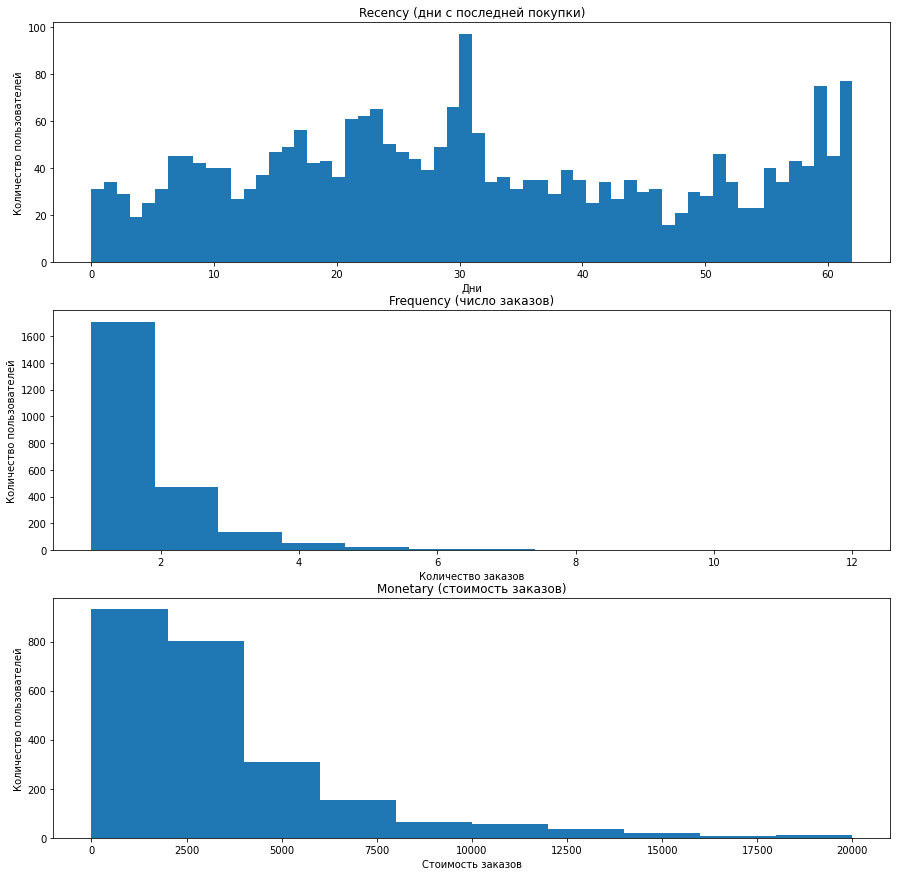

In [9]:
#recency
date_of_analysis = pd.to_datetime('2021-07-03', format="%Y-%m-%d")
df['order_recency'] = (date_of_analysis - df['datetime']).dt.days
df_orders = df[df['event'] == 'order']


df_rfm = df_orders.groupby('user_id').agg(
    recency=('datetime', lambda x: (date_of_analysis - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('revenue', 'sum')
).reset_index()

print(df_rfm)
    
fig, axes = plt.subplots(3,1, figsize=(15,15))

# Recency
axes[0].hist(df_rfm['recency'], bins=60)
axes[0].set_title('Recency (дни с последней покупки)')
axes[0].set_xlabel('Дни')
axes[0].set_ylabel('Количество пользователей')

# Frequency
axes[1].hist(df_rfm['frequency'], bins=12)
axes[1].set_title('Frequency (число заказов)')
axes[1].set_xlabel('Количество заказов')
axes[1].set_ylabel('Количество пользователей')

# Monetary
axes[2].hist(df_rfm['monetary'], bins=np.arange(0, df_rfm['monetary'].quantile(0.99) + 2000, 2000))
axes[2].set_title('Monetary (стоимость заказов)')
axes[2].set_xlabel('Стоимость заказов')
axes[2].set_ylabel('Количество пользователей')

plt.show()



`RECENCY`  
На графике `recency` можно заметить, пики около 30 дней и 60 дней. Большая часть активных пользователей сделали заказы в течение последнего месяца, в целом график имеет форму ближе к равномерному распределению, что не является хорошим знаком, значит что пользователи не возвращались в продукт на протяжении 30-60 дней. В то же время многие пользователи сделали заказы недавно <30 дней назад. Таким образом можно выделить 3 сегмента пользователей "активные", "периодически возвращающиеся" и "спящие". При дескретизации есть смысл указывать границы интервалов вручную (хотя в задании ниже сказано разбить на 3 равные группы)

`FREQUENCY`   
График `frequency` демонстрирует преобладание ползователей с низкой частотой заказов. В целом, это нормально

`MONETARY`  
Распределение имеет перекос влево: больше половины всех заказов до 5000, также есть много заказов от 5 до 8 тысяч. Есть и редкие заказы стоимостью более 10000 - это киты, они представляют особый интерес для бизнеса, как наиболее лояльные клиенты.


**Задача 3.2.** Выделите **RFM-сегменты** и изучите распределение пользователей по ним.
    
Примените следующие подходы к выделению RFM сегментов:
- **Recency** — разделите на три равные группы.
- **Frequency** —  разделите на три группы: 
    - пользователи с 1 заказом (F-сегмент с небольшим количеством заказов);
    - пользователи с 2 заказами (F-сегмент со средним количеством заказов);
    - пользователи с 3 и более заказами (F-сегмент с большим количеством заказов).
- **Monetary** — разделите на три группы по 33-му и 66-му перцентилям.
    
После этого посчитайте количество покупателей в каждом сегменте, сделайте промежуточные выводы и напишите рекомендации.

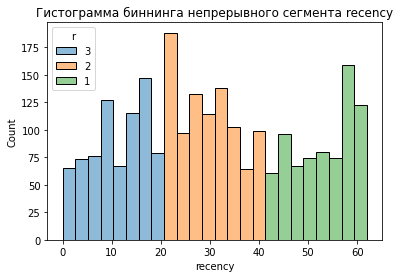

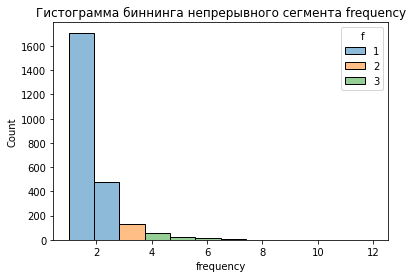

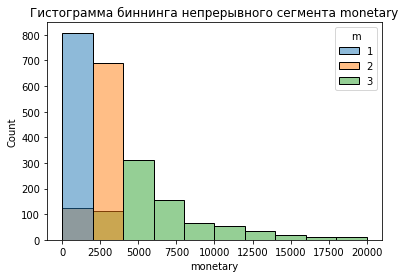

In [10]:
df_rfm['r'] = pd.cut(df_rfm['recency'], bins=3 , labels=[3,2,1])
df_rfm['f'] = pd.cut(df_rfm['frequency'], [1,2,3,15], labels=[1,2,3], include_lowest=True) 
df_rfm['m'] = pd.qcut(df_rfm['monetary'], q=3, labels=[1,2,3])

sns.histplot(data=df_rfm, x="recency", hue="r" ,bins=24)
# Настраиваем отображение
plt.title("Гистограмма биннинга непрерывного сегмента recency")
plt.show()

sns.histplot(data=df_rfm, x="frequency", hue="f", bins=12)
# Настраиваем отображение
plt.title("Гистограмма биннинга непрерывного сегмента frequency")
plt.show()

sns.histplot(data=df_rfm, x="monetary", hue="m", bins=np.arange(0, df_rfm['monetary'].quantile(0.99) + 2000, 2000))
# Настраиваем отображение
plt.title("Гистограмма биннинга непрерывного сегмента monetary")
plt.show()


In [11]:
df_rfm[['r','f','m']] = df_rfm[['r','f','m']].astype('str')
df_rfm['rfm_group'] = df_rfm['r'] + df_rfm['f'] + df_rfm['m']

rfm_group = df_rfm.groupby('rfm_group')['user_id'].nunique().reset_index(name='users_count')
rfm_group = rfm_group.sort_values('users_count', ascending=False)
rfm_group

,rfm_group,users_count
8,212,296
7,211,289
0,111,263
1,112,261
15,311,255
9,213,237
16,312,234
17,313,187
2,113,160
12,223,56


После RFM-сегментации видно что топ-3 по количеству это группы `212` `211` `111`. Этих пользователей можно охарактиризовать как относительно активных и делающих редкие заказы на небольшие суммы.  
Стоит ометить что у каждой из 3 групп `frequency (Частота заказов)` имеет минимальный показатель, а также низкий `monetary (Cтоимость)` - видимо это среднй класс, работяги, нормисы. У них нет потребности или возможности в том чтобы заказывать много и на большие суммы, поэтому чтобы повысить стоимость закзов, можно предлагать скидки на заказы от определной суммы или бесплатную доставку. Чтобы повысить частоту, можно настроить push-уведомления к праздникам.  

Есть и другая каста - группы `333` `323` `233` и `313` это так называемые киты, они же гигачады. У них много денюшек => много заказов, сервису доставки важно сохранять лояльность этих пользователей, потому что они делают большую часть выручки. Таким клиентам можно предложить персональные акции и скидки.


---

## 4. K-Means кластеризация

Чтобы лучше понимать поведение ресторанов и предлагать им персонализированные условия сотрудничества, а также создавать персонализированные предложения для пользователей, маркетологи запросили кластеризацию ресторанов по следующим параметрам:
- общее количество заказов;
- средняя стоимость заказа;
- общее число заказанных уникальных блюд (ассортимент ресторана).

С помощью метода K-Means разделите рестораны на кластеры, отражающие различные модели работы и целевые сегменты. Это позволяет выделить группы ресторанов с похожими характеристиками и разрабатывать для них эффективные маркетинговые стратегии.

**Задача 4.1.** Подготовьте данные для кластеризации и для каждого ресторана подсчитайте:
- общее количество заказов;
- средняя стоимость заказа;
- общее число заказанных уникальных блюд (ассортимент ресторана).

In [12]:
from sklearn.cluster import KMeans

data = df_orders.groupby('rest_id').agg(orders=('order_id', 'count'),
                                        avg_revenue=('revenue', 'mean'),
                                        objects=('object_id', 'nunique'))

data

,orders,avg_revenue,objects
rest_id,,,
1be5a933aab34fbab594bebba48e976e,144,2260.180222,28
1d6bb74687104fa1953924c9684fe624,108,2959.256481,19
2c6095730b514c189ee41c65f03febc3,8,1673.000000,4
3247a3b5f9494812a3c1a73c5b61f004,33,2777.209697,4
39b7eab4f4704ed2886fafe171489960,33,2011.269697,5
43e40bacafe8409bb5592877a42d737e,43,3313.064186,6
4a693ca500b44ba499f92a724aec5f17,107,2989.588785,12
4b9cde3378c447ed81c2c6d4854d4f7e,7,2544.000000,5
55d4027ac83e438f9f893892f6903409,1001,2674.652364,75


**Задача 4.2.** Нормализуйте данные и найдите оптимальное количество кластеров, использовав метод `.inertia_`. Постройте график зависимости инерции от числа кластеров (метод «локтя») и предположите оптимальное количество кластеров.

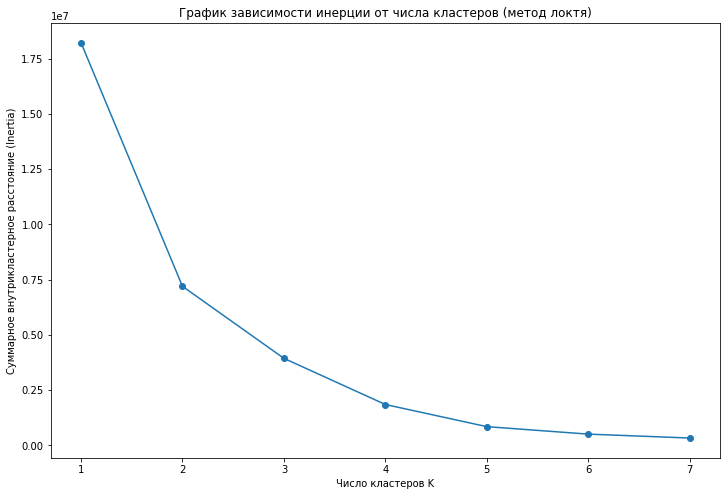

In [13]:
i=[]

for k in range(1, 8):
    km = KMeans(n_clusters=k)
    km.fit_transform(data)  # Обучаем модель и получаем координаты точек в пространстве кластеров
    i.append(km.inertia_)
    
# Строим график зависимости инерции от количества кластеров
plt.figure(figsize=(12, 8))
plt.plot(range(1, 8), i, marker='o')
plt.xlabel('Число кластеров K')  # Подпись оси X
plt.ylabel('Суммарное внутрикластерное расстояние (Inertia)')  # Подпись оси Y
plt.title('График зависимости инерции от числа кластеров (метод локтя)')  # Заголовок
plt.show()

Можно использовать 3 или 4 клсатера, > 4 - нецелесообразно

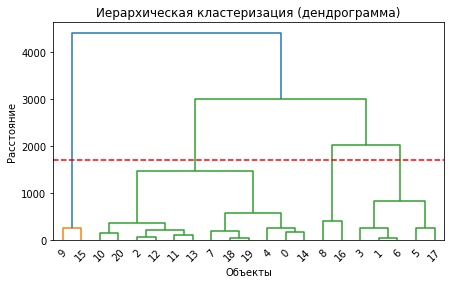

In [16]:
# Код ревьюера:
# Создадим таблицу связей:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(data, method = 'ward')

# Визуализируем таблицу связей:
plt.figure(figsize=(7, 4))  
dendrogram(linked, orientation='top')

plt.axhline(y=1700, color='r', linestyle='--')  
plt.title("Иерархическая кластеризация (дендрограмма)")
plt.xlabel("Объекты")
plt.ylabel("Расстояние")

plt.show()

**Задача 4.3.** Проведите кластеризацию, проанализируйте полученные результаты и рассчитайте средние значения по каждому кластеру.
    
После этого визуализируйте результаты, чтобы проследить зависимость признаков друг от друга. Постройте две визуализации, на которые нанесите все кластеры:
- средний чек в зависимости от количества заказов;
- количество блюд в зависимости от количества заказов.

После этого опишите каждый кластер в промежуточном выводе. 

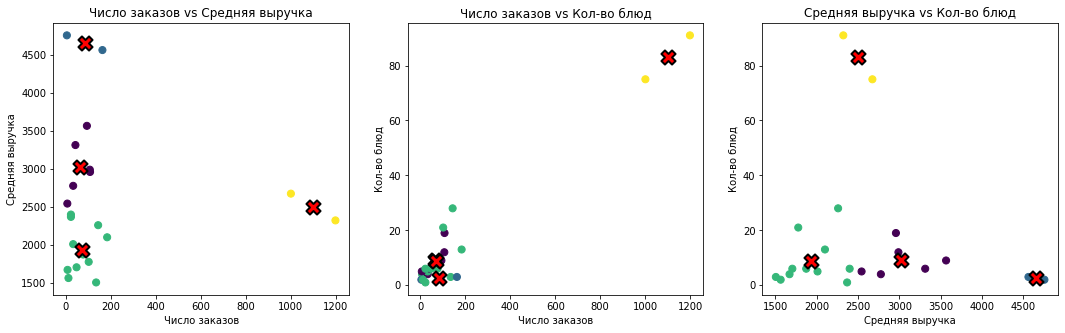

In [14]:
from itertools import combinations
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(data)

centroids = kmeans.cluster_centers_

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axs = {
    "orders": "Число заказов",
    "avg_revenue": "Средняя выручка",
    "objects": "Кол-во блюд"
}

feature_list = list(axs.keys())

for i, (x_key, y_key) in enumerate(combinations(feature_list, 2)):

    x_label = axs[x_key]
    y_label = axs[y_key]

    x_idx = feature_list.index(x_key)
    y_idx = feature_list.index(y_key)

    # Точки
    axes[i].scatter(
        data[x_key],
        data[y_key],
        c=labels,
        cmap='viridis',
        s=50
    )

    # Центроиды
    axes[i].scatter(
        centroids[:, x_idx],
        centroids[:, y_idx],
        s=200,
        c='red',
        edgecolors='black',
        linewidths=2,
        marker='X'
    )

    axes[i].set_xlabel(x_label)
    axes[i].set_ylabel(y_label)
    axes[i].set_title(f'{x_label} vs {y_label}')

plt.show()

4 кластера лучше разделяют пространство признаков.

Проанализируем полученные результаты
1) Визаулизация отношения "Число заказов / Средняя выручка" демонстрирует 4 ярко выраженных области:  
    1.1 Желтыми точками обозначены рестораны, с небольшим средним чеком и большим кол-вом заказо. Эти рестораны можно отнести к классу наиболее доступных  
    1.2 Зеленые и фиолетовые точки - рестораны с небольшим числом заказов. Стоит также отметить что зеленые точки - наименее успешные рестораны, у фиолетовых   дела со средним чеком получше, но число заказов также не радует  
    1.3 Синие точки - Премиум рестораны, немногие могут позволить себе дорогие блюда  
      

2) Визаулизация отношения "Число заказов / Кол-во блюд" демонстрирует 2 ярко выраженных области:    
    2.1 Желтые наиболее успешные рестораны, с наибольшим числом блюд и числом заказов  
    2.2 Синие, фиолетовые и зеленые точки имеют меньше позиций в меню и меньшее число заказов

    

---

## 5. Итоговый вывод и рекомендации

# Итоговые выводы и ключевые инсайты

## 1. Воронка и пользовательский опыт

Общая конверсия в покупку находится на хорошем уровне, что говорит о востребованности сервиса и корректной работе основной логики продукта.

Критическая точка потерь - этап подтверждения телефона, особенно для пользователей mobile. Наблюдается резкий провал конверсии на шаге `confirm_phone`, что может свидетельствовать о:

- проблемах с доставкой или задержкой SMS,
- неудобном UX формы,
- негативном эффекте недавних изменений со стороны разработки.

**Рекомендации:**
- провести технический аудит этапа подтверждения номера;
- проверить стабильность и скорость доставки SMS;
- упростить UX (автозаполнение, уменьшение количества шагов);
- протестировать альтернативные сценарии (A/B-тест).

Это наиболее очевидная точка быстрого роста конверсии.

---

## 2. RFM-сегментация пользователей

### Основной сегмент - «средний класс» (212, 211, 111)

Характеристики:
- низкая частота заказов,
- невысокий средний чек,
- заказы совершаются эпизодически.

Это самая многочисленная аудитория.

**Рекомендации:**
- стимулировать рост среднего чека (бесплатная доставка от порога, скидки при заказе от определённой суммы);
- повышать частоту заказов через триггерные push-уведомления и акции к праздникам.

---

### «Киты» (333, 323, 233, 313)

Характеристики:
- высокая частота заказов,
- высокий средний чек,
- значительный вклад в выручку.

Это стратегически важный сегмент.

**Рекомендации:**
- внедрить персонализированные предложения;
- разработать VIP-программу лояльности;
- обеспечить приоритетную поддержку и эксклюзивные акции.

Задача - удержание и рост LTV.

---

## 3. Сегментация ресторанов (K-means)

Выделено 4 кластера ресторанов:

1. Массовые и доступные - низкий чек, высокий объём заказов.  
   -> Оптимизация логистики и масштабирование.

2. Слабые рестораны - низкий чек и низкий объём заказов.  
   -> Необходима поддержка, продвижение или пересмотр стратегии.

3. Премиум-сегмент - высокий чек, умеренный объём заказов.  
   -> Таргетировать на сегмент «китов».

4. Успешные рестораны с широким меню - много позиций и высокий объём заказов.  
   -> Ключевые партнёры для масштабирования.

Также прослеживается зависимость: большее количество позиций в меню коррелирует с большим числом заказов.

---

# Общий стратегический вывод

1. Главная зона краткосрочного роста - исправление этапа подтверждения телефона (особенно на mobile).
2. Основной потенциал роста выручки - увеличение частоты и среднего чека у массового сегмента.
3. Ключевая задача удержания - работа с высокодоходными пользователями («китами»).
4. Рестораны требуют дифференцированной стратегии развития в зависимости от кластера.

Фокус на UX мобильной регистрации и грамотной сегментации пользователей способен существенно повысить эффективность продукта и выручку.